<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA3/PROYECTOFINAL/GraphNeuralNetworks_TWITCH_2025_FINAL2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Graph Neural Network para TWITCH (base de Pytorch) - Proyecto 3

Las redes de jugadores de Twitch se presentaron en el artículo "Integración de nodos atribuidos a múltiples escalas" . Los nodos representan a los jugadores en Twitch y los bordes representan los seguidores entre ellos. Las características de los nodos representan las incrustaciones de los juegos jugados por los usuarios de Twitch. La tarea consiste en predecir si un usuario transmite contenido para adultos.

**Integrantes:**

- Luis Alejandro Garzón Ramirez
- Zorayda Acevedo Jimenez
- Yulieth Danitza Aguillón Ortega

# **Install and import packages**

In [1]:
!pip install torch-geometric
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.6.0+cu124.html
!pip install pyg_lib --no-index -f https://data.pyg.org/whl/torch-2.6.0+cu124.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.9 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 37.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 18.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 37.8 MB/s eta 0:00:00


In [2]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

# **0. Cargar los datos de Pythorch datasets**

Carga y normalización de datos



In [4]:
!pip install torch-geometric torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.0.0+cpu.html

from torch_geometric.datasets import Twitch
from torch_geometric.transforms import NormalizeFeatures
import torch
from torch_geometric.nn import GCNConv
import torch.nn.functional as F

# Cargar dataset Twitch (la red de Alemania: 'DE')
dataset = Twitch(root='data/Twitch', name='DE', transform=NormalizeFeatures())
data = dataset[0]

Looking in links: https://data.pyg.org/whl/torch-2.0.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.1 MB/s eta 0:00:00


/usr/local/lib/python3.11/dist-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: /usr/local/lib/python3.11/dist-packages/torch_sparse/_version_cpu.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "
Processing...
Done!


# **1. Descripcion/entendimientos de los datos - Yulieth**





El conjunto de datos contiene un solo grafo, compuesto por:

- Número de nodos: 9,498
- Número de características por nodo: 128
- Número de clases: 2 (es decir, existen dos posibles etiquetas para clasificar los nodos)
En cuanto a la estructura del grafo, se observa lo siguiente:

- Las aristas no son dirigidas, lo que indica que las conexiones entre nodos son bidireccionales.
- El grafo no contiene nodos aislados, es decir, todos los nodos están conectados al menos a otro nodo.
- El grafo sí contiene bucles, lo que significa que algunos nodos están conectados consigo mismos.

In [ ]:
# Print information about the dataset
print(f'Dataset: {dataset}')
print('---------------')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of nodes: {data.x.shape[0]}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

# Print information about the graph
print(f'\nGraph:')
print('------')
print(f'Edges are directed: {data.is_directed()}')
print(f'Graph has isolated nodes: {data.has_isolated_nodes()}')
print(f'Graph has loops: {data.has_self_loops()}')

Dataset: Twitch()
---------------
Number of graphs: 1
Number of nodes: 9498
Number of features: 128
Number of classes: 2

Graph:
------
Edges are directed: False
Graph has isolated nodes: False
Graph has loops: True


In [ ]:
from collections import Counter
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

# Conversión a NetworkX
G = to_networkx(data, to_undirected=True)

Información general de la base:


Class distribution:
 Class 0: 3756 nodes
 Class 1: 5742 nodes

Degree statistics:
 Average degree: 34.25
 Max degree: 4261
 Min degree: 3
 Graph density: 0.003606
 Total number of triangles: 603088
 Average clustering coefficient: 0.2009
 Global transitivity: 0.0465
 Number of connected components: 1
 Largest component size: 9498 nodes

Centrality analysis:
 Top 5 nodes by degree centrality:
  Node 7787: 0.4487
  Node 9206: 0.1924
  Node 2684: 0.1809
  Node 1638: 0.1511
  Node 2914: 0.1431
 Top 5 nodes by betweenness centrality:
  Node 7787: 0.2912
  Node 9206: 0.0798
  Node 2684: 0.0418
  Node 1638: 0.0311
  Node 2914: 0.0270


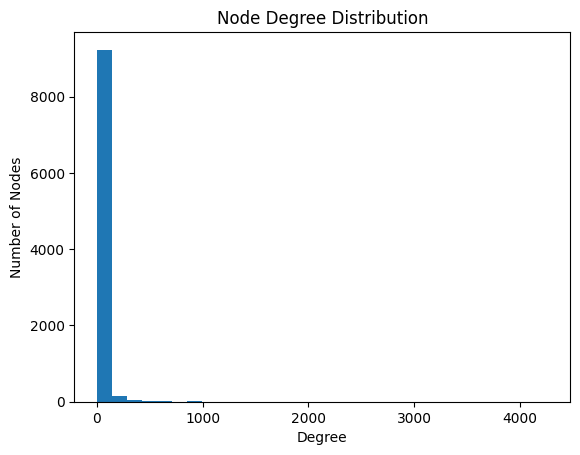

In [ ]:
# Distribución de clases
print('\nClass distribution:')
class_counts = Counter(data.y.tolist())
for cls, count in class_counts.items():
    print(f' Class {cls}: {count} nodes')

# Grado
degrees = [d for _, d in G.degree()]
print('\nDegree statistics:')
print(f' Average degree: {sum(degrees)/len(degrees):.2f}')
print(f' Max degree: {max(degrees)}')
print(f' Min degree: {min(degrees)}')

# Densidad
density = nx.density(G)
print(f' Graph density: {density:.6f}')

# Triángulos
triangles_dict = nx.triangles(G)
total_triangles = sum(triangles_dict.values()) // 3
print(f' Total number of triangles: {total_triangles}')

# Clustering
avg_clustering = nx.average_clustering(G)
transitivity = nx.transitivity(G)
print(f' Average clustering coefficient: {avg_clustering:.4f}')
print(f' Global transitivity: {transitivity:.4f}')

# Componentes conexas
components = list(nx.connected_components(G))
num_components = len(components)
largest_cc = max(components, key=len)
print(f' Number of connected components: {num_components}')
print(f' Largest component size: {len(largest_cc)} nodes')

# Centralidades
print('\nCentrality analysis:')
degree_centrality = nx.degree_centrality(G)
closeness_centrality = nx.closeness_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)

# Top 5 nodos por centralidad de grado
top_deg = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print(' Top 5 nodes by degree centrality:')
for node, score in top_deg:
    print(f'  Node {node}: {score:.4f}')

# Top 5 nodos por betweenness
top_bet = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print(' Top 5 nodes by betweenness centrality:')
for node, score in top_bet:
    print(f'  Node {node}: {score:.4f}')

# Visualizar distribución de grado
plt.hist(degrees, bins=30)
plt.title('Node Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Number of Nodes')
plt.show()

In [ ]:
# Eficiencia global
efficiency = nx.global_efficiency(G)
print(f' Global efficiency: {efficiency:.4f}')

 Global efficiency: 0.3891


In [ ]:
# Asortatividad
print('\nAssortativity metrics:')
try:
    degree_assortativity = nx.degree_assortativity_coefficient(G)
    print(f' Degree assortativity coefficient: {degree_assortativity:.4f}')
except Exception as e:
    print(f' Could not compute degree assortativity: {e}')

# Asortatividad por atributo (por ejemplo, clase del nodo)
if hasattr(data, 'y'):
    try:
        # Añadir atributo de clase al grafo de NetworkX
        for i, label in enumerate(data.y.tolist()):
            G.nodes[i]['class'] = int(label)

        class_assortativity = nx.attribute_assortativity_coefficient(G, 'class')
        print(f' Class assortativity coefficient: {class_assortativity:.4f}')
    except Exception as e:
        print(f' Could not compute class assortativity: {e}')


Assortativity metrics:
 Degree assortativity coefficient: -0.1095
 Class assortativity coefficient: 0.1691


#  **1.1 Visualizing the graph**

In [ ]:
edge_index_list = pd.DataFrame(data.edge_index.numpy().T, columns=['start_node','end_node'])

In [ ]:
G = nx.from_pandas_edgelist(edge_index_list, "start_node", "end_node")

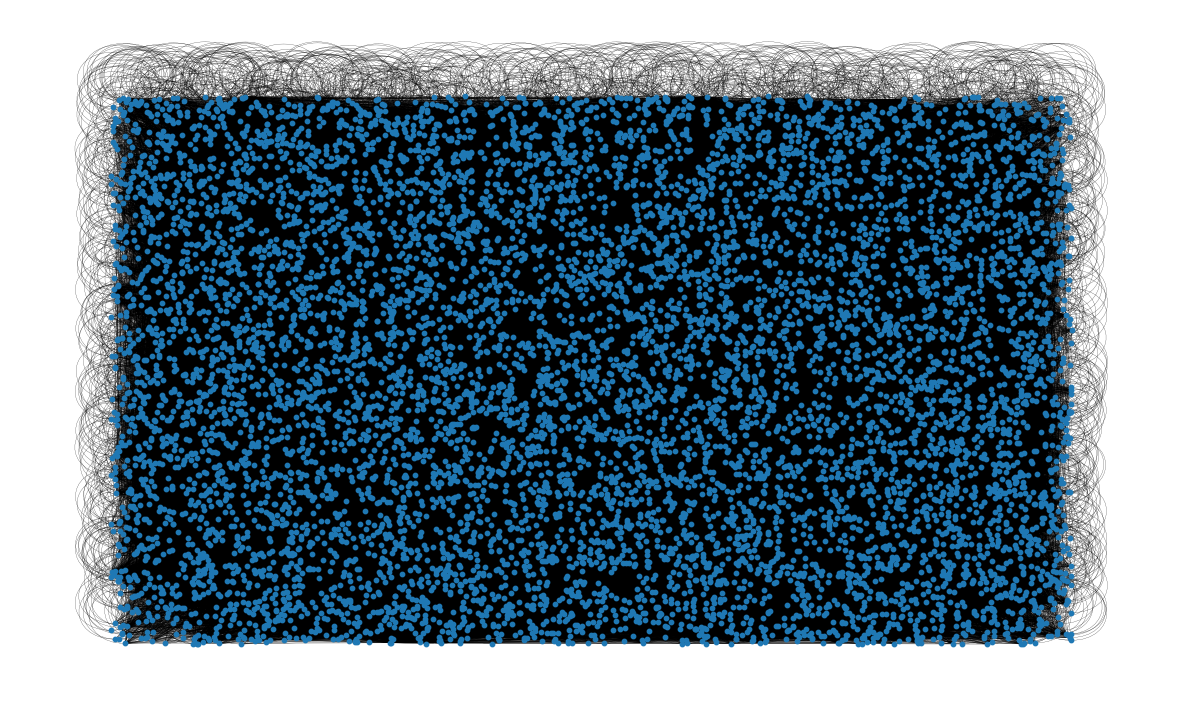

In [ ]:
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
plot_options = {"node_size": 10, "with_labels": False, "width": 0.15}
nx.draw_networkx(G, pos=nx.random_layout(G), ax=ax, **plot_options)

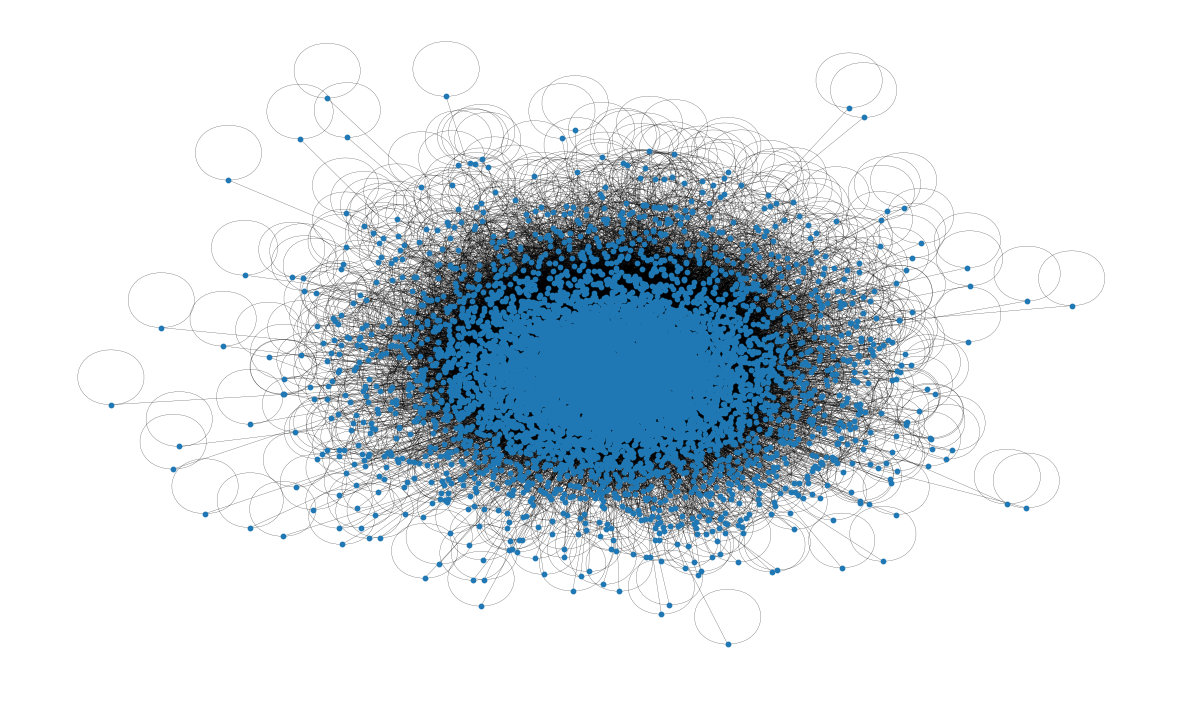

In [ ]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

In [ ]:
# Filtering at least 5 connections
edge_index_list_filtered = edge_index_list.groupby("start_node").filter(lambda x: len(x) > 5)
edge_index_list_filtered.head()

,start_node,end_node
0,0,9206
1,9206,0
2,0,7787
3,7787,0
4,0,2145


In [ ]:
G = nx.from_pandas_edgelist(edge_index_list_filtered, "start_node", "end_node")

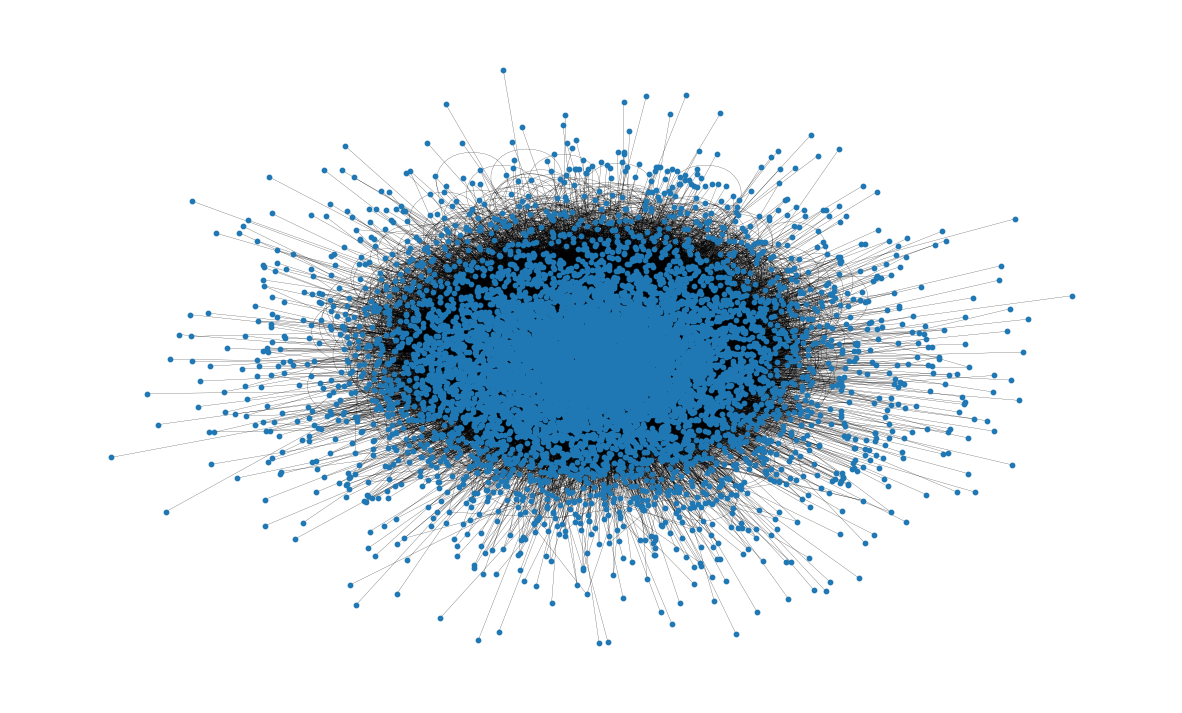

In [ ]:
pos = nx.spring_layout(G, iterations=15, seed=1721)
fig, ax = plt.subplots(figsize=(15, 9))
ax.axis("off")
nx.draw_networkx(G, pos=pos, ax=ax, **plot_options)

# **2. Preparación de los datos (ZORAYDA)**



# **2.1 Normalización DATASET**

In [5]:
#VERIFICACION VALORES VECTORES ANTES DE NORMALIZAR
print(f"Min value: {data.x.min():.4f}")
print(f"Max value: {data.x.max():.4f}")
print(f"Mean: {data.x.mean():.4f}")
print(f"Norma promedio: {torch.norm(data.x, p=2, dim=1).mean():.4f}")

Min value: 0.0000
Max value: 0.1006
Mean: 0.0078
Norma promedio: 0.1265


In [6]:
#NORMALIZACION DE DATA.X (CARACTERISTICAS DE LOS NODOS)

data.x = F.normalize(data.x, p=2, dim=1)

# Verificación
norms = torch.norm(data.x, p=2, dim=1)
print(f"Norma promedio manual: {norms.mean():.4f}")
print(f"¿Todas ≈1?: {torch.allclose(norms, torch.ones_like(norms), atol=1e-3)}")

Norma promedio manual: 1.0000
¿Todas ≈1?: True


In [7]:
#VERIFICACION VALORES VECTORES DESPUES DE NORMALIZAR
print(f"Min value: {data.x.min():.4f}")
print(f"Max value: {data.x.max():.4f}")
print(f"Mean: {data.x.mean():.4f}")
print(f"Norma promedio: {torch.norm(data.x, p=2, dim=1).mean():.4f}")

Min value: 0.0000
Max value: 0.6859
Mean: 0.0620
Norma promedio: 1.0000


# **2.2 División Dataset en TRAIN, TEST, VAL**

In [8]:
from sklearn.model_selection import train_test_split
import torch

# Suponiendo que ya tienes cargado tu objeto de datos como 'data'
# Total de nodos
num_nodes = data.num_nodes

# Crear índices aleatorios
indices = torch.randperm(num_nodes)

# División: 70% train, 10% val, 20% test
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=2/3, random_state=42)  # 2/3 de 30% es 20%, 1/3 es 10%

# Inicializar máscaras
data_train_mascara = torch.zeros(num_nodes, dtype=torch.bool)
data_val_mascara = torch.zeros(num_nodes, dtype=torch.bool)
data_test_mascara = torch.zeros(num_nodes, dtype=torch.bool)

# Asignar los nodos correspondientes
data_train_mascara[train_idx] = True
data_val_mascara[val_idx] = True
data_test_mascara[test_idx] = True

# Verificar la cantidad de nodos en cada conjunto
print(f"Nodos de entrenamiento: {data_train_mascara.sum().item()}")
print(f"Nodos de validación: {data_val_mascara.sum().item()}")
print(f"Nodos de prueba: {data_test_mascara.sum().item()}")

Nodos de entrenamiento: 6648
Nodos de validación: 950
Nodos de prueba: 1900


In [ ]:
data_val_mascara

tensor([False, False, False,  ..., False, False, False])

# **3. Modelos GNN**

# Modelo base 0 -  Graph Neural Network with Nodes Features - Alejandro

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
data.y = data.y.float()
#data.y = torch.argmax(data.y, dim=1)

In [ ]:
data.y

tensor([0., 1., 1.,  ..., 1., 0., 0.])

In [ ]:
from sklearn.metrics import classification_report

from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import confusion_matrix


In [ ]:
import torch
torch.manual_seed(0)
from torch.nn import Linear
import torch.nn.functional as F


def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [ ]:
import torch
torch.manual_seed(0)
from torch.nn import Linear, Dropout, BatchNorm1d
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score

class MLP(torch.nn.Module):
    def __init__(self, dim_in, dim_h, dropout_rate=0.5):
        super().__init__()
        self.linear1 = Linear(dim_in, dim_h)
        self.bn1 = BatchNorm1d(dim_h)
        self.dropout = Dropout(p=dropout_rate)
        self.linear2 = Linear(dim_h, 1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.linear2(x)
        return x  # 👉 sin sigmoid aquí, porque usamos BCEWithLogitsLoss

    def fit(self, data, epochs=100, lr=0.005, weight_decay=1e-3, patience=20):
        criterion = torch.nn.BCEWithLogitsLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=lr, weight_decay=weight_decay)

        self.train()
        best_val_acc = 0
        wait = 0

        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x).squeeze()
            loss = criterion(out[data_train_mascara], data.y[data_train_mascara].float())
            preds = (torch.sigmoid(out[data_train_mascara]) >= 0.5).int()
            acc = accuracy_score(data.y[data_train_mascara].cpu(), preds.cpu())
            loss.backward()
            optimizer.step()

            val_out = out[data_val_mascara]
            val_preds = (torch.sigmoid(val_out) >= 0.5).int()
            val_acc = accuracy_score(data.y[data_val_mascara].cpu(), val_preds.cpu())
            val_loss = criterion(val_out, data.y[data_val_mascara].float())

            if epoch % 20 == 0:
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:.2f}% | '
                      f'Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')

            if val_acc > best_val_acc:
                best_val_acc = val_acc
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered.")
                    break

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x).squeeze()
        out_test = out[data_test_mascara]
        probs = torch.sigmoid(out_test).cpu()
        preds = (probs >= 0.5).int()
        y_true = data.y[data_test_mascara].cpu()

        acc = accuracy_score(y_true, preds)
        precision = precision_score(y_true, preds, zero_division=0)
        recall = recall_score(y_true, preds, zero_division=0)
        auc = roc_auc_score(y_true, probs)

        # ⬇️ Aquí se añade el classification_report
        report = classification_report(y_true, preds, digits=2, zero_division=0, labels=[0,1])
        cm = confusion_matrix(y_true, preds, labels=[0,1])
        print("Confusion Matrix:\n", cm)

        print(f"\n[TEST RESULTS]")
        print(f"Test Accuracy:  {acc*100:.2f}%")
        print(f"Test Precision: {precision:.3f}")
        print(f"Test Recall:    {recall:.3f}")
        print(f"Test AUC:       {auc:.3f}")
        print("\nClassification Report:")
        print(report)

        return acc

In [ ]:
# Create MLP model
mlp = MLP(dataset.num_features, 16, 1)
print(mlp)

# Train
mlp.fit(data, epochs=100)

# Test
acc = mlp.test(data)
print(f'\nMLP test accuracy: {acc*100:.2f}%')

MLP(
  (linear1): Linear(in_features=128, out_features=16, bias=True)
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=1, inplace=False)
  (linear2): Linear(in_features=16, out_features=1, bias=True)
)
Epoch   0 | Train Loss: 0.704 | Train Acc: 39.64% | Val Loss: 0.70 | Val Acc: 40.11%
Epoch  20 | Train Loss: 0.693 | Train Acc: 60.36% | Val Loss: 0.69 | Val Acc: 59.89%
Epoch  40 | Train Loss: 0.685 | Train Acc: 60.36% | Val Loss: 0.69 | Val Acc: 59.89%
Early stopping triggered.
Confusion Matrix:
 [[   0  740]
 [   0 1160]]

[TEST RESULTS]
Test Accuracy:  61.05%
Test Precision: 0.611
Test Recall:    1.000
Test AUC:       0.492

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       740
           1       0.61      1.00      0.76      1160

    accuracy                           0.61      1900
   macro avg       0.31      0.50      0.38      1900
weighte

# Modelo 1 - Zorayda  - matriz de adyacencia


In [ ]:
#CREAR MATRIZ DE ADYACENCIA
from torch_geometric.utils import to_dense_adj

adjacency = to_dense_adj(data.edge_index)[0]
adjacency

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [ ]:
#NORMALIZA MATRIZ DE ADYACENCIA (codigo generado por chatgpt)
def normalize_adjacency(adj):
    deg = adj.sum(1)
    deg_inv_sqrt = torch.pow(deg, -0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0.0
    D_inv_sqrt = torch.diag(deg_inv_sqrt)
    return D_inv_sqrt @ adj @ D_inv_sqrt

adjacency = normalize_adjacency(adjacency)

In [ ]:
#Definición clase SparseLayer
import torch.nn as nn
class SparseLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, x, adjacency):
        h = torch.matmul(adjacency, x)
        return self.linear(h)

In [ ]:
# CREACION CLASE DEL MODELO
class GNN(torch.nn.Module):
    """Vanilla Graph Neural Network"""
    def __init__(self, dim_in, dim_h, dim_out):
        super().__init__()
        self.gnn1 = SparseLayer(dim_in, dim_h)
        self.gnn2 = SparseLayer(dim_h, dim_out)

    def forward(self, x, adjacency):
        h = self.gnn1(x, adjacency)
        h = torch.relu(h)
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.gnn2(h, adjacency)
        return F.log_softmax(h, dim=1)

    def fit(self, data, adjacency, epochs):
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=5e-4)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x, adjacency)
            loss = criterion(out[data_train_mascara], data.y[data_train_mascara])
            acc = accuracy(out[data_train_mascara].argmax(dim=1), data.y[data_train_mascara])
            loss.backward()
            optimizer.step()

            # métricas de entrenamiento
            if epoch % 20 == 0:
                print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}%')

    @torch.no_grad()
    def test(self, data, adjacency, mask):
      self.eval()
      out = self(data.x, adjacency)

    # (codigo generado por chatgpt)
      probs = torch.exp(out)
      positive_probs = probs[:, 1]  # clase positiva

    # Predicciones
      y_pred = probs.argmax(dim=1)[mask].cpu().numpy()
      y_true = data.y[mask].cpu().numpy()
      y_score = positive_probs[mask].cpu().numpy()

    # Métricas (codigo generado por chatgpt)
      acc = accuracy_score(y_true, y_pred)
      auc = roc_auc_score(y_true, y_score)
      cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
      report = classification_report(y_true, y_pred, labels=[0, 1], digits=3, zero_division=0)

    # Imprimir
      print("\n🔍 Resultados del modelo GNN:")
      print(f"Accuracy : {acc*100:.2f}%")
      print(f"AUC      : {auc:.3f}")
      print("Matriz de Confusión:")
      print(cm)
      print("\nReporte de Clasificación:")
      print(report)

      return acc, auc, cm, report


In [ ]:
# Crear el modelo GNN
gnn = GNN(data.num_features, 64, dataset.num_classes)
print(gnn)

data.y = data.y.long()

# Entrenamiento
gnn.fit(data, adjacency, epochs=150)

# Validación
val_acc, val_auc, val_cm, val_report = gnn.test(data, adjacency, data_val_mascara)
print(f'\nGNN validation accuracy: {val_acc*100:.2f}%')
print(f'GNN validation AUC: {val_auc:.3f}')

GNN(
  (gnn1): SparseLayer(
    (linear): Linear(in_features=128, out_features=64, bias=True)
  )
  (gnn2): SparseLayer(
    (linear): Linear(in_features=64, out_features=2, bias=True)
  )
)
Epoch   0 | Train Loss: 0.697 | Train Acc: 39.56%
Epoch  20 | Train Loss: 0.660 | Train Acc: 60.36%
Epoch  40 | Train Loss: 0.649 | Train Acc: 60.76%
Epoch  60 | Train Loss: 0.621 | Train Acc: 65.66%
Epoch  80 | Train Loss: 0.604 | Train Acc: 66.98%
Epoch 100 | Train Loss: 0.594 | Train Acc: 68.71%
Epoch 120 | Train Loss: 0.594 | Train Acc: 68.40%
Epoch 140 | Train Loss: 0.592 | Train Acc: 69.15%

🔍 Resultados del modelo GNN:
Accuracy : 64.63%
AUC      : 0.716
Matriz de Confusión:
[[120 261]
 [ 75 494]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0      0.615     0.315     0.417       381
           1      0.654     0.868     0.746       569

    accuracy                          0.646       950
   macro avg      0.635     0.592     0.581       950
w

In [ ]:
# Prueba Final
test_acc, test_auc, test_cm, test_report = gnn.test(data, adjacency, data_test_mascara)
print(f'\nGNN test accuracy: {test_acc*100:.2f}%')
print(f'GNN test AUC: {test_auc:.3f}')


🔍 Resultados del modelo GNN:
Accuracy : 66.47%
AUC      : 0.724
Matriz de Confusión:
[[264 476]
 [161 999]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0      0.621     0.357     0.453       740
           1      0.677     0.861     0.758      1160

    accuracy                          0.665      1900
   macro avg      0.649     0.609     0.606      1900
weighted avg      0.655     0.665     0.639      1900


GNN test accuracy: 66.47%
GNN test AUC: 0.724


# Modelo 2 GCN - Yulieth

In [ ]:
import torch
import torch.nn.functional as F
import random
import numpy as np
from torch_geometric.nn import GCNConv
from sklearn.metrics import confusion_matrix, roc_auc_score, accuracy_score, classification_report

# 🔒 Fijar la semilla para reproducibilidad
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)  # Llamada a la función

# Definir modelo GCN
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)  # 👉 salida 1 para binaria

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x.view(-1)  # 👉 salida en vector 1D

# Función de entrenamiento
def train(model, data, mask, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[mask], data.y[mask].float())
    loss.backward()
    optimizer.step()
    return loss.item()

# Función de evaluación
@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    logits = out[mask]
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).int().cpu().numpy()
    labels = data.y[mask].cpu().numpy()

    acc = accuracy_score(labels, preds)
    auc = roc_auc_score(labels, probs.cpu().numpy())
    cm = confusion_matrix(labels, preds)
    report = classification_report(labels, preds, output_dict=True)

    return acc, auc, cm, report

# Inicialización
model = GCN(data.num_features, hidden_channels=16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.BCEWithLogitsLoss()

# Entrenamiento
for epoch in range(1, 201):
    loss = train(model, data, data_train_mascara, optimizer, criterion)
    if epoch % 20 == 0:
        acc, auc, cm, _ = evaluate(model, data, data_val_mascara)
        print(f"Epoch {epoch:03d} | Val Acc: {acc:.2f} | Val AUC: {auc:.2f}")
        print("Matriz de confusión (val):\n", cm)

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 020 | Val Acc: 0.60 | Val AUC: 0.62
Matriz de confusión (val):
 [[  0 381]
 [  0 569]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Epoch 040 | Val Acc: 0.60 | Val AUC: 0.62
Matriz de confusión (val):
 [[  0 381]
 [  0 569]]
Epoch 060 | Val Acc: 0.60 | Val AUC: 0.64
Matriz de confusión (val):
 [[  6 375]
 [  4 565]]
Epoch 080 | Val Acc: 0.61 | Val AUC: 0.66
Matriz de confusión (val):
 [[ 43 338]
 [ 34 535]]
Epoch 100 | Val Acc: 0.62 | Val AUC: 0.69
Matriz de confusión (val):
 [[ 61 320]
 [ 41 528]]
Epoch 120 | Val Acc: 0.64 | Val AUC: 0.70
Matriz de confusión (val):
 [[ 94 287]
 [ 55 514]]
Epoch 140 | Val Acc: 0.63 | Val AUC: 0.71
Matriz de confusión (val):
 [[ 94 287]
 [ 60 509]]
Epoch 160 | Val Acc: 0.66 | Val AUC: 0.71
Matriz de confusión (val):
 [[136 245]
 [ 78 491]]
Epoch 180 | Val Acc: 0.66 | Val AUC: 0.72
Matriz de confusión (val):
 [[145 236]
 [ 83 486]]
Epoch 200 | Val Acc: 0.64 | Val AUC: 0.71
Matriz de confusión (val):
 [[112 269]
 [ 72 497]]


In [ ]:
import pandas as pd

# Prueba final
test_acc, test_auc, test_cm, test_report = evaluate(model, data, data_test_mascara)

print("\n🔍 Resultados en el conjunto de prueba:")
print(f"Test Accuracy: {test_acc:.2f}")
print(f"Test AUC: {test_auc:.2f}")

# Matriz de confusión como tabla
conf_matrix_df = pd.DataFrame(
    test_cm,
    index=["Verdadero 0", "Verdadero 1"],
    columns=["Predicho 0", "Predicho 1"]
)
print("\n📊 Matriz de Confusión:")
display(conf_matrix_df)  # display() se usa en notebooks como Google Colab

# Reporte de clasificación como tabla
report_df = pd.DataFrame(test_report).transpose()
print("\n📋 Reporte de Clasificación:")
display(report_df)


🔍 Resultados en el conjunto de prueba:
Test Accuracy: 0.66
Test AUC: 0.72

📊 Matriz de Confusión:


,Predicho 0,Predicho 1
Verdadero 0,244,496
Verdadero 1,148,1012



📋 Reporte de Clasificación:


,precision,recall,f1-score,support
0,0.622449,0.329730,0.431095,740.000000
1,0.671088,0.872414,0.758621,1160.000000
accuracy,0.661053,0.661053,0.661053,0.661053
macro avg,0.646768,0.601072,0.594858,1900.000000
weighted avg,0.652144,0.661053,0.631058,1900.000000


# Modelo 3 GAT - Alejandro

In [9]:
import torch
torch.manual_seed(1)
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, GCNConv
from torch.nn import Linear, Dropout

import matplotlib.pyplot as plt
import numpy as np
from torch_geometric.utils import degree
from collections import Counter

from torch_geometric.datasets import Planetoid

In [10]:
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [11]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.6/386.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 21.1 MB/s eta 0:00:00


In [ ]:
# este es el codigo de optimizacion se deja coimentado ya que su ejecucion es muy pesada
'''import optuna
from torch_geometric.nn import Node2Vec

def objective(trial):
    embedding_dim = trial.suggest_categorical('embedding_dim', [64, 128, 184, 256])
    walk_length = trial.suggest_int('walk_length', 10, 40)
    context_size = trial.suggest_int('context_size', 5, 20)
    walks_per_node = trial.suggest_int('walks_per_node', 5, 30)
    num_negative_samples = trial.suggest_int('num_negative_samples', 1, 10)
    p = trial.suggest_float('p', 0.25, 4.0, log=True)
    q = trial.suggest_float('q', 0.25, 4.0, log=True)
    lr = trial.suggest_float('lr', 1e-4, 0.05, log=True)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    node2vec = Node2Vec(
        data.edge_index,
        embedding_dim=embedding_dim,
        walk_length=walk_length,
        context_size=context_size,
        walks_per_node=walks_per_node,
        num_negative_samples=num_negative_samples,
        p=p,
        q=q,
        sparse=True
    ).to(device)

    loader = node2vec.loader(batch_size=128, shuffle=True)
    optimizer = torch.optim.SparseAdam(node2vec.parameters(), lr=lr)

    def train():
        node2vec.train()
        total_loss = 0
        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = node2vec.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        return total_loss / len(loader)

    for epoch in range(1, 50):  # menos épocas para probar rápido
        loss = train()

    return loss  # Optuna minimizará esta pérdida

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30)

print("Mejores parámetros:", study.best_params)
print("Mejor pérdida:", study.best_value)'''

'import optuna\nfrom torch_geometric.nn import Node2Vec\n\ndef objective(trial):\n    embedding_dim = trial.suggest_categorical(\'embedding_dim\', [64, 128, 184, 256])\n    walk_length = trial.suggest_int(\'walk_length\', 10, 40)\n    context_size = trial.suggest_int(\'context_size\', 5, 20)\n    walks_per_node = trial.suggest_int(\'walks_per_node\', 5, 30)\n    num_negative_samples = trial.suggest_int(\'num_negative_samples\', 1, 10)\n    p = trial.suggest_float(\'p\', 0.25, 4.0, log=True)\n    q = trial.suggest_float(\'q\', 0.25, 4.0, log=True)\n    lr = trial.suggest_float(\'lr\', 1e-4, 0.05, log=True)\n\n    device = torch.device(\'cuda\' if torch.cuda.is_available() else \'cpu\')\n\n    node2vec = Node2Vec(\n        data.edge_index,\n        embedding_dim=embedding_dim,\n        walk_length=walk_length,\n        context_size=context_size,\n        walks_per_node=walks_per_node,\n        num_negative_samples=num_negative_samples,\n        p=p,\n        q=q,\n        sparse=True\n  

In [12]:
from torch_geometric.nn import Node2Vec
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Para reproducibilidad completa (puede afectar el rendimiento)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

# Inicializamos Node2Vec
embedding_dim = 184
node2vec = Node2Vec(
    data.edge_index,
    embedding_dim=embedding_dim,
    walk_length=34,
    context_size=5,
    walks_per_node=30,
    num_negative_samples=1,
    p=0.3435545538097828,
    q=2.2912543597348267,
    sparse=True
)

# Entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
node2vec = node2vec.to(device)
loader = node2vec.loader(batch_size=128, shuffle=True)
optimizer = torch.optim.SparseAdam(list(node2vec.parameters()), lr=0.01)

def train_node2vec():
    node2vec.train()
    total_loss = 0
    for pos_rw, neg_rw in loader:
        optimizer.zero_grad()
        loss = node2vec.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

for epoch in range(1, 120):
    loss = train_node2vec()
    if epoch % 10 == 0:
        print(f'Epoch {epoch:03d}, Loss: {loss:.4f}')

Epoch 010, Loss: 0.9872
Epoch 020, Loss: 0.9634
Epoch 030, Loss: 0.9615
Epoch 040, Loss: 0.9605
Epoch 050, Loss: 0.9594
Epoch 060, Loss: 0.9579
Epoch 070, Loss: 0.9565
Epoch 080, Loss: 0.9558
Epoch 090, Loss: 0.9550
Epoch 100, Loss: 0.9544
Epoch 110, Loss: 0.9537


In [13]:
node2vec.eval()
with torch.no_grad():
    z = node2vec(torch.arange(data.num_nodes, device=device))

# Concatenamos embeddings con features originales
data.x1 = torch.cat([data.x.to(device), z], dim=1)

In [14]:
def accuracy(y_pred, y_true):
    """Calculate accuracy."""
    return torch.sum(y_pred == y_true) / len(y_true)

In [15]:
# Suponiendo que `data.y` contiene las etiquetas binarias
labels_train = data.y[data_train_mascara]

# Contar cantidad de ejemplos de cada clase
num_pos = (labels_train == 1).sum()
num_neg = (labels_train == 0).sum()

# Calcular pos_weight
pos_weight = num_neg / num_pos
print(f"Peso positivo para BCEWithLogitsLoss: {pos_weight:.2f}")

Peso positivo para BCEWithLogitsLoss: 0.66


In [16]:
import torch
import torch.nn.functional as F
from torch.nn import Linear, Dropout, BatchNorm1d
from torch_geometric.nn import GATv2Conv
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, classification_report
)

# Función auxiliar
def accuracy(preds, labels):
    return (preds == labels).sum().item() / labels.size(0)

# Modelo GAT con capa intermedia
class GAT(torch.nn.Module):
    def __init__(self, dim_in, dim_h, heads=8):
        super().__init__()
        self.gat1 = GATv2Conv(dim_in, dim_h, heads=heads)
        self.bn1 = BatchNorm1d(dim_h * heads)

        self.gat_middle = GATv2Conv(dim_h * heads, dim_h, heads=1)
        self.bn_middle = BatchNorm1d(dim_h)

        self.gat2 = GATv2Conv(dim_h, 1, heads=1)  # salida binaria

    def forward(self, x, edge_index):
        h = F.dropout(x, p=0.45, training=self.training)
        h = self.gat1(h, edge_index)
        h = self.bn1(h)
        h = F.elu(h)

        h = F.dropout(h, p=0.45, training=self.training)
        h = self.gat_middle(h, edge_index)
        h = self.bn_middle(h)
        h = F.elu(h)

        h = F.dropout(h, p=0.45, training=self.training)
        h = self.gat2(h, edge_index)

        return h.view(-1)  # para BCEWithLogitsLoss

    def fit(self, data, epochs=300):
        pos_weight_tensor = torch.tensor([pos_weight], device=data.y.device)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
        optimizer = torch.optim.Adam(self.parameters(), lr=0.0001361, weight_decay=0.00001)

        self.train()
        for epoch in range(epochs + 1):
            optimizer.zero_grad()
            out = self(data.x1, data.edge_index)
            train_out = out[data_train_mascara]
            train_labels = data.y[data_train_mascara].float()
            loss = criterion(train_out, train_labels)
            preds = (torch.sigmoid(train_out) > 0.45).long()
            acc = accuracy(preds, train_labels.long())
            loss.backward()
            optimizer.step()

            if epoch % 20 == 0:
                val_out = out[data_val_mascara]
                val_labels = data.y[data_val_mascara].float()
                val_loss = criterion(val_out, val_labels)
                val_preds = (torch.sigmoid(val_out) > 0.45).long()
                val_acc = accuracy(val_preds, val_labels.long())
                print(f"Epoch {epoch:>3} | "
                      f"Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | "
                      f"Val Loss: {val_loss:.3f} | Val Acc: {val_acc*100:.2f}%")

    @torch.no_grad()
    def test(self, data):
        self.eval()
        out = self(data.x1, data.edge_index)
        test_out = out[data_test_mascara]
        test_probs = torch.sigmoid(test_out)
        test_preds = (test_probs > 0.45).long()
        test_labels = data.y[data_test_mascara].long()

        acc = accuracy_score(test_labels.cpu(), test_preds.cpu())
        precision = precision_score(test_labels.cpu(), test_preds.cpu())
        recall = recall_score(test_labels.cpu(), test_preds.cpu())
        auc = roc_auc_score(test_labels.cpu(), test_probs.cpu())
        report = classification_report(test_labels.cpu(), test_preds.cpu(), digits=3)

        print(f"\nTest Metrics:")
        print(f"Accuracy : {acc*100:.2f}%")
        print(f"Precision: {precision:.3f}")
        print(f"Recall   : {recall:.3f}")
        print(f"AUC      : {auc:.3f}")
        print(f"\nClassification Report:\n{report}")
        return acc

In [19]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Para reproducibilidad completa (puede afectar el rendimiento)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed(42)

data = data.to(device)
gat = GAT(312,dim_h=120, heads=6).to(device)
print(gat)
gat.fit(data, epochs=500)
acc = gat.test(data)
print(f'GAT test accuracy: {acc*100:.2f}%')

GAT(
  (gat1): GATv2Conv(312, 120, heads=6)
  (bn1): BatchNorm1d(720, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat_middle): GATv2Conv(720, 120, heads=1)
  (bn_middle): BatchNorm1d(120, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (gat2): GATv2Conv(120, 1, heads=1)
)
Epoch   0 | Train Loss: 0.655 | Train Acc: 58.94% | Val Loss: 0.670 | Val Acc: 57.16%
Epoch  20 | Train Loss: 0.538 | Train Acc: 63.33% | Val Loss: 0.546 | Val Acc: 61.79%
Epoch  40 | Train Loss: 0.512 | Train Acc: 66.91% | Val Loss: 0.530 | Val Acc: 65.05%
Epoch  60 | Train Loss: 0.501 | Train Acc: 67.96% | Val Loss: 0.525 | Val Acc: 65.68%
Epoch  80 | Train Loss: 0.492 | Train Acc: 68.64% | Val Loss: 0.531 | Val Acc: 67.16%
Epoch 100 | Train Loss: 0.495 | Train Acc: 68.52% | Val Loss: 0.510 | Val Acc: 67.16%
Epoch 120 | Train Loss: 0.486 | Train Acc: 69.16% | Val Loss: 0.520 | Val Acc: 65.89%
Epoch 140 | Train Loss: 0.488 | Train Acc: 68.92% | Val Loss: 0.534 | Val Acc: 66.11